# חיזוי מהירות הליכה לרובוט מלווה

מודל ‎XGBoost‎ שמנבא את מהירות ההליכה של אדם **3 צעדים קדימה** (≈0.30 שניות בקצב 10Hz),
כדי שרובוט מלווה יקדים ויתאים את תנועתו במקום להגיב באיחור.

האימון, הוולידציה והבדיקה מבוצעים על נתוני חיישן אמיתיים מהרובוט, עם חלוקה לפי אדם
כך שהבדיקה נעשית על נסיינים שהמודל מעולם לא ראה.

In [1]:
from google.colab import drive
import glob
import os
import pandas as pd

# Mount Google Drive (approve access in the pop-up window).
drive.mount('/content/drive')

Mounted at /content/drive


## הערה על מקור הנתונים

בגרסאות קודמות אומן המודל על מאגר ‎HuGaDB‎, שבו אין מהירות אמיתית — היא חושבה
מהאצה דרך נוסחה, כלומר מהירות מפוברקת. כאן אנו מאמנים ובודקים אך ורק על קבצי
החיישן האמיתיים של הרובוט, שכבר מכילים מהירות נמדדת (`speed_mps`).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

# טעינת הנתונים, ניקוי ובניית מאפיינים

לכל קובץ: סינון קוצי רעש פיזיקליים, החלקה, ובניית 55 מאפיינים (50 לגים + 5 מאפייני מגמה).
החלוקה לאימון, ולידציה ובדיקה נעשית לפי אדם (`GroupShuffleSplit`) כדי למנוע דליפת מידע בין נסיין שמופיע ביותר מסט אחד.

In [3]:
import glob, os, gc
import pandas as pd, numpy as np
from sklearn.model_selection import GroupShuffleSplit

HORIZON   = 3      # how many steps ahead to predict (~0.30 s at 10 Hz)
MAX_SPEED = 5.0    # physical ceiling: anything above this is sensor noise, not real speed
SMOOTH    = 5      # smoothing window applied after filtering. Set to 1 to disable.

# Person id = name of the file's parent folder:  Experiments/<person>/<file>.csv
def person_of(path):
    return os.path.basename(os.path.dirname(path))

def build_one(fn, horizon):
    df = pd.read_csv(fn)
    if 'speed_mps' not in df.columns:
        return None
    s = pd.to_numeric(df['speed_mps'], errors='coerce').dropna().reset_index(drop=True)
    if len(s) < 60:
        return None

    # Step 1: remove physically impossible spikes (sensor noise).
    s = s.mask(s > MAX_SPEED).mask(s < 0)
    s = s.ffill().bfill()

    # Step 2: smooth the cleaned signal.
    if SMOOTH > 1:
        s = s.rolling(SMOOTH, min_periods=1).mean()

    # Build features: 50 lags + rolling stats + trend terms.
    f = pd.DataFrame()
    for i in range(0, 50):
        f[f'lag_{i}'] = s.shift(i)
    f['roll_mean_5']  = s.rolling(5).mean()
    f['roll_std_5']   = s.rolling(5).std()
    f['roll_mean_10'] = s.rolling(10).mean()
    f['trend_5']  = s - s.shift(5)
    f['trend_10'] = s - s.shift(10)
    f['y']      = s.shift(-horizon)
    f['person'] = person_of(fn)
    return f.dropna()

# Load every recording from the experiments folder.
folder_path = '/content/drive/MyDrive/Colab Notebooks/data'
all_files = glob.glob(os.path.join(folder_path, '*', '*.csv'))
print(f"Found {len(all_files)} files")

frames = [b for b in (build_one(fn, HORIZON) for fn in all_files) if b is not None]
data = pd.concat(frames, ignore_index=True)

groups = data['person'].values
feature_cols = [c for c in data.columns if c not in ('y', 'person')]
X = data[feature_cols].values.astype(np.float32)
y = data['y'].values.astype(np.float32)

# Split 1: Holdout Test Set (20%)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_val_idx, te_idx = next(gss_test.split(X, y, groups))

X_temp, y_temp, groups_temp = X[tr_val_idx], y[tr_val_idx], groups[tr_val_idx]
X_test, y_test = X[te_idx], y[te_idx]
naive_test = X_test[:, 0]
chg = np.abs(data['trend_5'].values)[te_idx]

# Split 2: Train vs Validation (20% of the remaining for Validation)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, val_idx = next(gss_val.split(X_temp, y_temp, groups_temp))

X_train, y_train = X_temp[tr_idx], y_temp[tr_idx]
X_val, y_val = X_temp[val_idx], y_temp[val_idx]

n_tr_people = len(set(groups_temp[tr_idx]))
n_val_people = len(set(groups_temp[val_idx]))
n_te_people = len(set(groups[te_idx]))
assert set(groups_temp[tr_idx]).isdisjoint(set(groups[te_idx])), "Leakage: train/test"
assert set(groups_temp[tr_idx]).isdisjoint(set(groups_temp[val_idx])), "Leakage: train/val"

print(f"Horizon: {HORIZON} steps | train: {X_train.shape} from {n_tr_people} people\n"
      f" | val: {X_val.shape} from {n_val_people} people\n"
      f" | test: {X_test.shape} from {n_te_people} unseen people")
gc.collect()

Found 297 files
Horizon: 3 steps | train: (29370, 55) from 73 people
 | val: (7422, 55) from 19 people
 | test: (15872, 55) from 23 unseen people


0

# בניית המודל ואימונו

מאמנים ‎XGBoost‎ עם עצירה מוקדמת (early stopping) על סט הוולידציה, ומנטרים את השגיאה הסופית על סט הבדיקה הנקי.

In [4]:
TARGET = 'speed_mps'
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:squarederror',
                       max_depth=3,
                       learning_rate=0.01)

reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=100)

# Final clean evaluation on test set
test_preds = reg.predict(X_test)
print(f"\nFinal Test RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.3f} m/s")

X_train shape: (29370, 55)
y_train shape: (29370,)
X_val shape: (7422, 55)
y_val shape: (7422,)
X_test shape: (15872, 55)
y_test shape: (15872,)

[0]	validation_0-rmse:0.92001	validation_1-rmse:0.94258
[100]	validation_0-rmse:0.39416	validation_1-rmse:0.40233
[200]	validation_0-rmse:0.24369	validation_1-rmse:0.24350
[300]	validation_0-rmse:0.20970	validation_1-rmse:0.20786
[400]	validation_0-rmse:0.20103	validation_1-rmse:0.19944
[500]	validation_0-rmse:0.19721	validation_1-rmse:0.19635
[600]	validation_0-rmse:0.19452	validation_1-rmse:0.19437
[700]	validation_0-rmse:0.19209	validation_1-rmse:0.19263
[800]	validation_0-rmse:0.18957	validation_1-rmse:0.19053
[900]	validation_0-rmse:0.18723	validation_1-rmse:0.18889
[999]	validation_0-rmse:0.18507	validation_1-rmse:0.18740

Final Test RMSE: 0.168 m/s


# ביצועים לפי מצב תנועה

נשווה את המודל לניחוש הנאיבי (persistence — "המהירות הבאה זהה לנוכחית") בשלושה חתכים:
כלל הבדיקה, מצבי מעבר (25% הדגימות הדינמיות ביותר), ומצב יציב. הסיפור המרכזי נמצא ב**מצבי המעבר**.

In [5]:
def stats(name, p, mask=None):
    a, q = (y_test, p) if mask is None else (y_test[mask], p[mask])
    print(f"{name:12s} | RMSE {np.sqrt(mean_squared_error(a,q)):.3f}" \
          f" | MAE {mean_absolute_error(a,q):.3f} | R2 {r2_score(a,q)*100:.1f}%")

trans = chg > np.percentile(chg, 75)   # top 25% most dynamic samples = transition states
print("===== All test =====");         stats("XGBoost", test_preds);        stats("Naive", naive_test)
print("\n===== Transition states ====="); stats("XGBoost", test_preds, trans); stats("Naive", naive_test, trans)
print("\n===== Steady state =====");    stats("XGBoost", test_preds, ~trans); stats("Naive", naive_test, ~trans)

===== All test =====
XGBoost      | RMSE 0.168 | MAE 0.126 | R2 90.5%
Naive        | RMSE 0.191 | MAE 0.139 | R2 87.7%

===== Transition states =====
XGBoost      | RMSE 0.206 | MAE 0.158 | R2 85.1%
Naive        | RMSE 0.240 | MAE 0.180 | R2 79.8%

===== Steady state =====
XGBoost      | RMSE 0.153 | MAE 0.115 | R2 92.1%
Naive        | RMSE 0.171 | MAE 0.125 | R2 90.1%


## גרף: שגיאה מול אופק החיזוי

הגרף משווה את שגיאת המודל (אדום) לשגיאת הניחוש הנאיבי (ירוק) ככל שמנסים לחזות רחוק יותר קדימה.
ככל שהאופק גדל, שתי השגיאות עולות — אבל המודל שומר על פער עקבי לטובתו, והפער הגדול ביותר נמצא
באופקים הקצרים, בדיוק הטווח שבו הרובוט צריך להקדים. בחרנו אופק של 3 צעדים כאיזון בין הקדמה מספקת לדיוק גבוה.

Horizon 1: model=0.061 | naive=0.072 | improvement=15.5%
Horizon 2: model=0.116 | naive=0.135 | improvement=14.1%
Horizon 3: model=0.168 | naive=0.191 | improvement=12.0%
Horizon 5: model=0.257 | naive=0.277 | improvement=7.1%
Horizon 8: model=0.314 | naive=0.341 | improvement=8.0%
Horizon 10: model=0.333 | naive=0.364 | improvement=8.5%


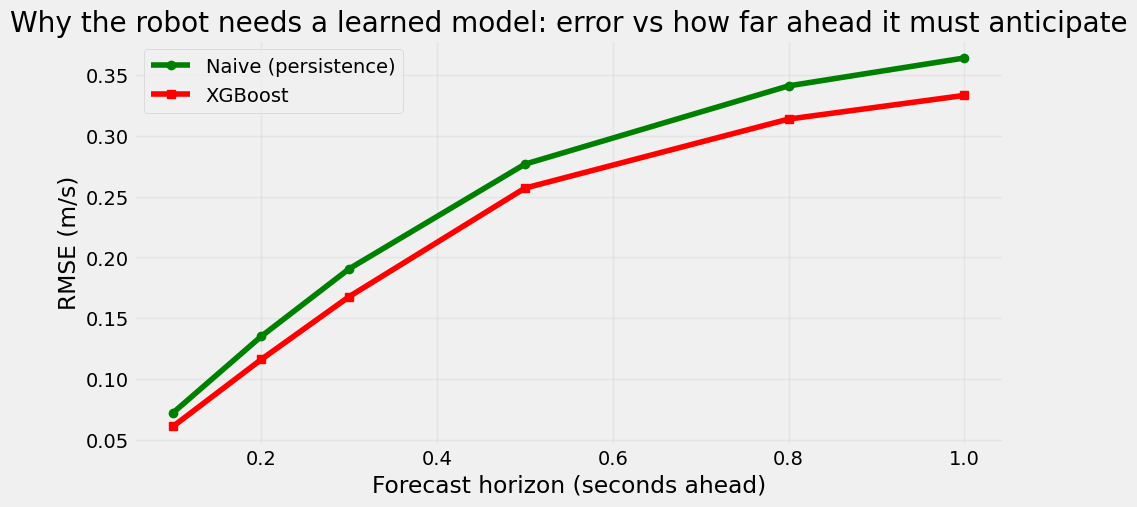

In [6]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

def eval_horizon(h):
    # Build the dataset for horizon h, split by person, train, and return RMSE of model vs naive.
    frames = [b for b in (build_one(fn, h) for fn in all_files) if b is not None]
    d = pd.concat(frames, ignore_index=True)
    g  = d['person'].values
    fc = [c for c in d.columns if c not in ('y', 'person')]
    Xx = d[fc].values.astype(np.float32)
    yy = d['y'].values.astype(np.float32)
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(Xx, yy, g))

    # We skip validation here just for the sake of plotting error curve vs horizon efficiently.
    mdl = xgb.XGBRegressor(n_estimators=1000, max_depth=3, learning_rate=0.01,
                           random_state=42, n_jobs=-1).fit(Xx[tr], yy[tr])

    rm = np.sqrt(mean_squared_error(yy[te], mdl.predict(Xx[te])))
    rn = np.sqrt(mean_squared_error(yy[te], Xx[te, 0]))   # naive = lag_0
    return rm, rn

horizons = [1, 2, 3, 5, 8, 10]
m_rmse, n_rmse = [], []
for h in horizons:
    rm, rn = eval_horizon(h)
    m_rmse.append(rm); n_rmse.append(rn)
    print(f"Horizon {h}: model={rm:.3f} | naive={rn:.3f} | improvement={100*(1-rm/rn):.1f}%")

plt.figure(figsize=(10,5))
sec = [h*0.10 for h in horizons]
plt.plot(sec, n_rmse, 'o-', label='Naive (persistence)', color='green')
plt.plot(sec, m_rmse, 's-', label='XGBoost', color='red')
plt.xlabel('Forecast horizon (seconds ahead)'); plt.ylabel('RMSE (m/s)')
plt.title('Why the robot needs a learned model: error vs how far ahead it must anticipate')
plt.legend(); plt.grid(alpha=.3); plt.show()

# חלוקת אימון / ולידציה / בדיקה

## גרף: רצף האימון מול הבדיקה
הגרף מציג את מהירות היעד לאורך דגימות האימון, הוולידציה והבדיקה.
הוא ממחיש שהסטים מורכבים מנסיינים נפרדים, ושטווח המהירויות בחלקים דומה.

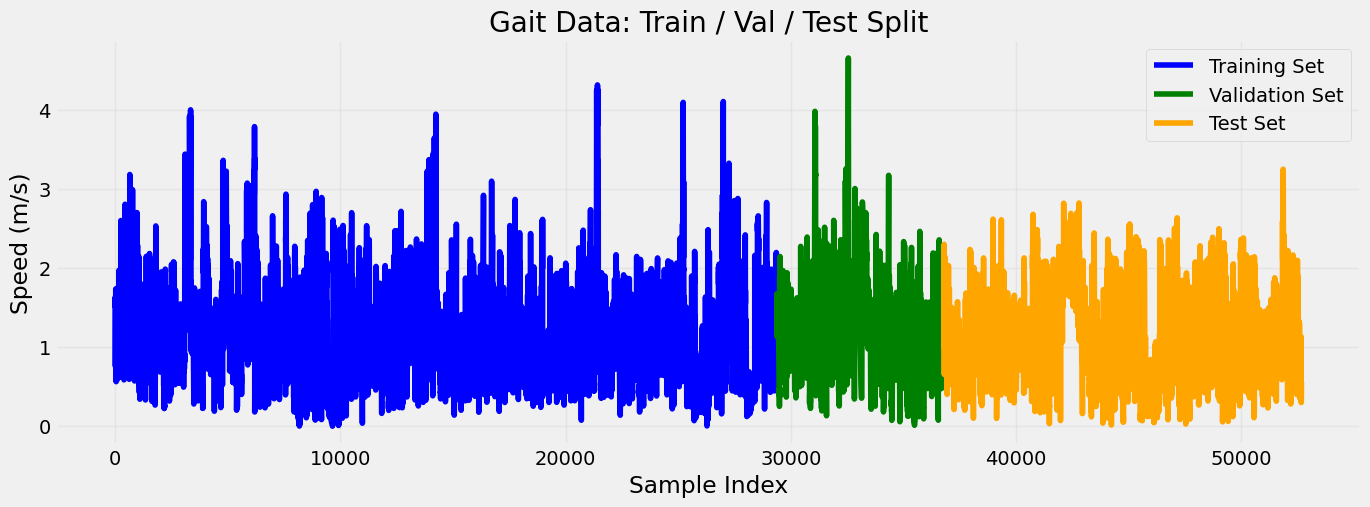

In [7]:
# Visualize the train / val / test split along the sample order.
plt.figure(figsize=(15, 5))
plt.plot(range(len(y_train)), y_train, label='Training Set', color='blue')
plt.plot(range(len(y_train), len(y_train) + len(y_val)), y_val, label='Validation Set', color='green')
plt.plot(range(len(y_train) + len(y_val), len(y_train) + len(y_val) + len(y_test)), y_test, label='Test Set', color='orange')
plt.title('Gait Data: Train / Val / Test Split')
plt.xlabel('Sample Index')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## גרף: חלון מקרוב של אות המהירות
מבט מקרוב על קטע רציף מתוך נתוני האימון, כדי לראות את מבנה אות ההליכה לאחר הניקוי וההחלקה —
התנודתיות הטבעית של מהירות ההליכה ברמת הדגימה הבודדת.

Total length of y_train: 29370
Plotting from index 1000 to 1500


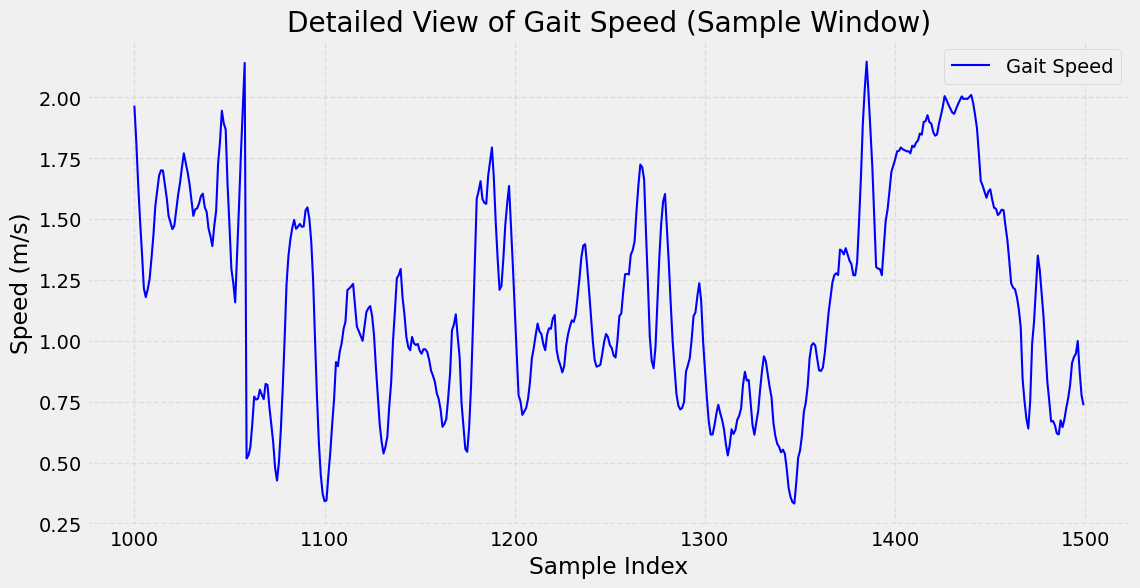

In [8]:
print(f"Total length of y_train: {len(y_train)}")

# Pick a safe window; fall back to the start/end if the data is shorter than expected.
actual_start = 1000 if len(y_train) > 1000 else 0
actual_end   = 1500 if len(y_train) > 1500 else len(y_train)
print(f"Plotting from index {actual_start} to {actual_end}")

y_slice = y_train[actual_start:actual_end]
if isinstance(y_slice, np.ndarray):
    y_slice = np.nan_to_num(y_slice)

plt.figure(figsize=(12, 6))
if len(y_slice) > 0:
    x_axis = range(actual_start, actual_start + len(y_slice))
    plt.plot(x_axis, y_slice, color='blue', linewidth=1.5, label='Gait Speed')
    plt.title('Detailed View of Gait Speed (Sample Window)')
    plt.xlabel('Sample Index')
    plt.ylabel('Speed (m/s)')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
plt.show()

# חשיבות המאפיינים

## גרף: על מה המודל מסתמך
הגרף מציג את 15 המאפיינים המשפיעים ביותר. המהירות הנוכחית (lag_0) היא החזקה ביותר — הגיוני —
אך המודל נשען גם על מאפייני מגמה וממוצעים נעים, וזה מה שמאפשר לו לזהות האצה או האטה ולהקדים אותה.

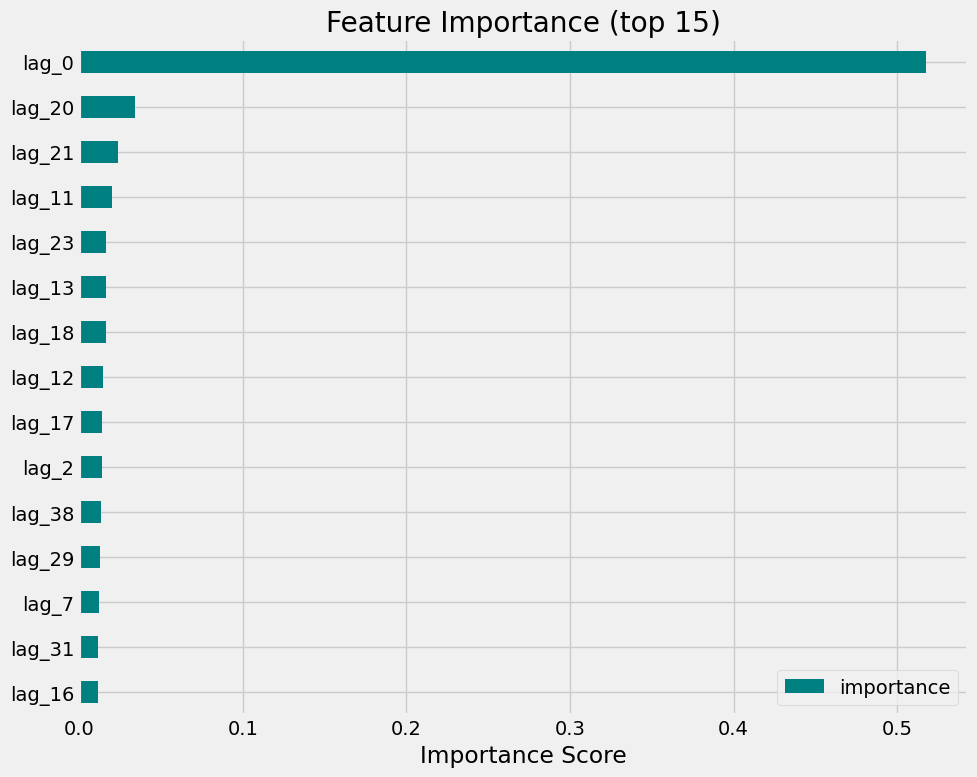

In [9]:
# Feature names in the exact order built by build_one: 50 lags + 5 trend/rolling features.
feature_names = (
    [f'lag_{i}' for i in range(0, 50)]          # lag_0 .. lag_49
    + ['roll_mean_5', 'roll_std_5', 'roll_mean_10', 'trend_5', 'trend_10']
)

assert len(feature_names) == reg.feature_importances_.shape[0], \
    f"{len(feature_names)} names vs {reg.feature_importances_.shape[0]} features"

fi = pd.DataFrame(data=reg.feature_importances_,
                  index=feature_names,
                  columns=['importance'])

# Show only the top 15 (55 bars would be too dense to read).
fi.sort_values('importance').tail(15).plot(
    kind='barh', title='Feature Importance (top 15)', figsize=(10, 8), color='teal')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## השוואה לקוד הנוכחי של הרובוט (Robot Baseline)

בקר המעקב הנוכחי (`follow_controller`) **אינו מנבא** את העתיד. הוא אומד את המהירות ה*נוכחית* (גזירת מיקום מ-UWB) ומניע את רכיב ה-feed-forward דרך מסנן EMA:

`ff = a*v + (1-a)*ff`  ,  `a = FF_ALPHA = 0.2`

כלומר ההערכה שמניעה את הרובוט = EMA סיבתי של המהירות עד עכשיו, שהרובוט מתייחס אליה כאל יעד המהירות הקרוב. נשחזר אותה מתוך הלגים שכבר קיימים בכל שורת בדיקה (`X_test[:, :50]` = lag_0..lag_49) ונשווה את שלושת המנבאים על אותו `y_test` בדיוק — אותו split הוגן של 23 הנסיינים שהמודל לא ראה.

In [10]:
import numpy as np
from sklearn.metrics import mean_squared_error

# --- מנבא #3: הקוד הנוכחי של הרובוט (ללא חיזוי) ---
# EMA סיבתי על המהירות: ema(t) = a * sum_k (1-a)^k * lag_k   (הלגים = עמודות 0..49)
FF_ALPHA = 0.2
w = FF_ALPHA * (1 - FF_ALPHA) ** np.arange(50)
w = w / w.sum()                      # נרמול (טרנקציה ל-50 איברים, שארית זניחה)
robot_pred = X_test[:, :50] @ w      # הערכת הרובוט לכל שורת בדיקה

rmse = lambda a, b: np.sqrt(mean_squared_error(a, b))
rmse_robot = rmse(y_test, robot_pred)
rmse_naive = rmse(y_test, naive_test)
rmse_model = rmse(y_test, test_preds)   # test_preds חושב כבר בתא האימון (reg.predict(X_test))

print(f"Robot current code (EMA a=0.2) : RMSE = {rmse_robot:.4f}")
print(f"Naive (persistence)            : RMSE = {rmse_naive:.4f}")
print(f"Our XGBoost model              : RMSE = {rmse_model:.4f}")
print('-'*48)
print(f"Model improves on NAIVE by : {100*(rmse_naive-rmse_model)/rmse_naive:5.1f}%")
print(f"Model improves on ROBOT by : {100*(rmse_robot-rmse_model)/rmse_robot:5.1f}%")
print(f"Robot's EMA vs naive       : {100*(rmse_robot-rmse_naive)/rmse_naive:5.1f}%  (lag added by smoothing)")

Robot current code (EMA a=0.2) : RMSE = 0.2563
Naive (persistence)            : RMSE = 0.1906
Our XGBoost model              : RMSE = 0.1679
------------------------------------------------
Model improves on NAIVE by :  11.9%
Model improves on ROBOT by :  34.5%
Robot's EMA vs naive       :  34.5%  (lag added by smoothing)


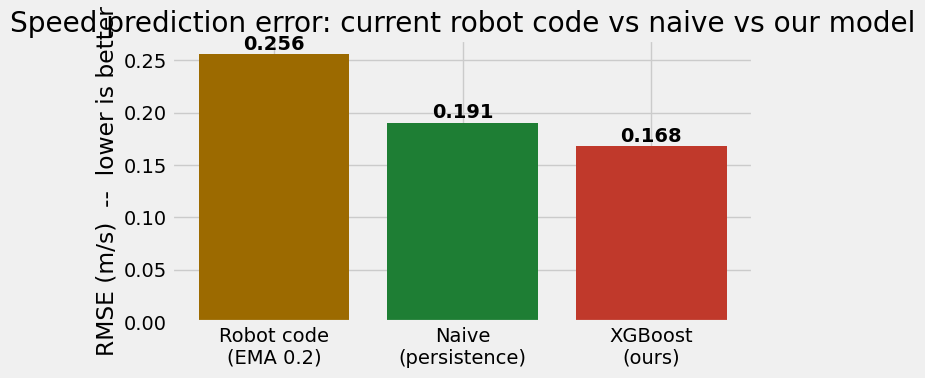

In [11]:
import matplotlib.pyplot as plt
labels = ['Robot code\n(EMA 0.2)', 'Naive\n(persistence)', 'XGBoost\n(ours)']
vals   = [rmse_robot, rmse_naive, rmse_model]
colors = ['#9C6A00', '#1E7E34', '#C0392B']
plt.figure(figsize=(7,4))
bars = plt.bar(labels, vals, color=colors)
plt.ylabel('RMSE (m/s)  --  lower is better')
plt.title('Speed prediction error: current robot code vs naive vs our model')
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+0.004, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## יציבות התוצאה — Group K-Fold Cross-Validation (תיקון נקודת תורפה #2)

עד כה כל המספרים (RMSE=0.168, R²=90.5% וכו') הגיעו מ-**חלוקה אחת** בלבד (`random_state=42`) — כלומר תלויים באילו 23 אנשים ספציפית נפלו בבדיקה. כדי לדעת עד כמה התוצאה יציבה, מריצים כאן **GroupKFold** עם 5 קפלים: כל אדם עובר בדיוק פעם אחת בתפקיד 'בדיקה', על מודל שאומן בלעדיו (עם early stopping על val שנחתך מתוך קבוצת האימון של אותו fold, בדיוק כמו בפייפליין הראשי). בסוף מדווחים ממוצע ± סטיית תקן על פני 5 המודלים — זה מחליף את המספר הבודד בטווח אמין.

In [12]:
from sklearn.model_selection import GroupKFold

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

fold_rmse, fold_mae, fold_r2, fold_skill = [], [], [], []

for fold, (trainval_idx, test_idx) in enumerate(gkf.split(X, y, groups), start=1):
    X_trainval, y_trainval, groups_trainval = X[trainval_idx], y[trainval_idx], groups[trainval_idx]
    X_test_f, y_test_f = X[test_idx], y[test_idx]
    naive_test_f = X_test_f[:, 0]

    # לחתוך val מתוך קבוצת האימון של ה-fold, לצורך early stopping -- באותה שיטה כמו בפייפליין הראשי
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr_idx, val_idx = next(gss.split(X_trainval, y_trainval, groups_trainval))
    X_tr, y_tr = X_trainval[tr_idx], y_trainval[tr_idx]
    X_v,  y_v  = X_trainval[val_idx], y_trainval[val_idx]

    mdl = xgb.XGBRegressor(base_score=0.5, booster='gbtree', n_estimators=1000,
                            early_stopping_rounds=50, objective='reg:squarederror',
                            max_depth=3, learning_rate=0.01)
    mdl.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_v, y_v)], verbose=False)

    preds = mdl.predict(X_test_f)
    rmse_f = np.sqrt(mean_squared_error(y_test_f, preds))
    mae_f  = mean_absolute_error(y_test_f, preds)
    r2_f   = r2_score(y_test_f, preds) * 100
    rmse_naive_f = np.sqrt(mean_squared_error(y_test_f, naive_test_f))
    skill_f = 100 * (rmse_naive_f - rmse_f) / rmse_naive_f

    fold_rmse.append(rmse_f); fold_mae.append(mae_f); fold_r2.append(r2_f); fold_skill.append(skill_f)
    print(f"Fold {fold} ({len(set(groups_trainval))}\u2192{len(set(groups[test_idx]))} people) : "
          f"RMSE={rmse_f:.3f} | MAE={mae_f:.3f} | R2={r2_f:.1f}% | skill vs naive={skill_f:.1f}%")

print('-'*70)
print(f"RMSE            : {np.mean(fold_rmse):.3f} \u00b1 {np.std(fold_rmse):.3f}")
print(f"MAE             : {np.mean(fold_mae):.3f} \u00b1 {np.std(fold_mae):.3f}")
print(f"R2              : {np.mean(fold_r2):.1f}% \u00b1 {np.std(fold_r2):.1f}%")
print(f"Skill vs naive  : {np.mean(fold_skill):.1f}% \u00b1 {np.std(fold_skill):.1f}%")

Fold 1 (97→18 people) : RMSE=0.170 | MAE=0.126 | R2=91.3% | skill vs naive=10.0%
Fold 2 (93→22 people) : RMSE=0.166 | MAE=0.122 | R2=89.8% | skill vs naive=12.5%
Fold 3 (93→22 people) : RMSE=0.224 | MAE=0.160 | R2=86.5% | skill vs naive=7.5%
Fold 4 (89→26 people) : RMSE=0.176 | MAE=0.129 | R2=90.9% | skill vs naive=10.3%
Fold 5 (88→27 people) : RMSE=0.186 | MAE=0.137 | R2=88.8% | skill vs naive=12.0%
----------------------------------------------------------------------
RMSE            : 0.184 ± 0.021
MAE             : 0.135 ± 0.013
R2              : 89.5% ± 1.7%
Skill vs naive  : 10.4% ± 1.8%


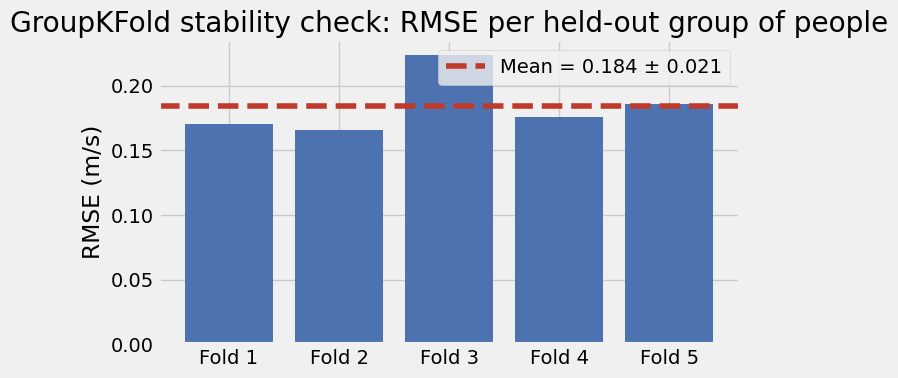

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,4))
xs = range(1, N_FOLDS+1)
plt.bar(xs, fold_rmse, color='#4C72B0')
plt.axhline(np.mean(fold_rmse), color='#C0392B', linestyle='--',
            label=f'Mean = {np.mean(fold_rmse):.3f} \u00b1 {np.std(fold_rmse):.3f}')
plt.xticks(xs, [f'Fold {i}' for i in xs])
plt.ylabel('RMSE (m/s)')
plt.title('GroupKFold stability check: RMSE per held-out group of people')
plt.legend()
plt.tight_layout(); plt.show()